# Agente Connect-4 basado en Monte Carlo Tree Search

## Objetivo e Idea principal

Analizar el desempeño de un agente basado en Monte Carlo Tree Search (MCTS) usando simulaciones aleatorias y selección UCB para Connect-4.

## Idea principal

El agente primero revisa jugadas ganadoras o amenazas inmediatas y luego utiliza simulaciones Monte Carlo para estimar cuáles movimientos producen mejores resultados.

In [1]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append(".")

In [4]:
import importlib.util

spec = importlib.util.spec_from_file_location(
    "policy",
    "groups/Group C/policy.py"
)

module = importlib.util.module_from_spec(spec)

spec.loader.exec_module(module)

Nicrack = module.Nicrack

In [5]:
agent = Nicrack()

print(agent)

In [5]:
board = np.zeros((6, 7))

start = time.time()

move = agent.act(board)

end = time.time()

print("Movimiento:", move)
print("Tiempo:", end - start)

Movimiento: 3
Tiempo: 0.09500813484191895


## Experimento 1: Tiempo de decisión del agente

En este experimento se mide el tiempo que tarda el agente en seleccionar una acción utilizando Monte Carlo Tree Search.

In [18]:
times = []

for _ in range(20):

    board = np.zeros((6, 7))

    start = time.time()

    agent.act(board)

    end = time.time()

    times.append(end - start)

print("Tiempo promedio:", np.mean(times))
print("Tiempo mínimo:", np.min(times))
print("Tiempo máximo:", np.max(times))

Tiempo promedio: 0.013595259189605713
Tiempo mínimo: 0.010144948959350586
Tiempo máximo: 0.028970003128051758


### Interpretación del experimento inicial

Los resultados obtenidos muestran que el agente basado en Monte Carlo Tree Search (MCTS) mantiene tiempos de decisión relativamente bajos y estables durante las ejecuciones realizadas.

El tiempo promedio de respuesta fue cercano a 0.012 segundos, mientras que los valores mínimo y máximo permanecieron dentro de un rango reducido. Esto indica que el algoritmo puede tomar decisiones de forma eficiente incluso realizando múltiples simulaciones internas antes de seleccionar una acción.

Además, la baja variación entre tiempos sugiere que el comportamiento computacional del agente es consistente y no presenta incrementos bruscos de complejidad en escenarios simples como un tablero vacío.

Este experimento permite observar cómo MCTS puede equilibrar exploración y eficiencia computacional, logrando tiempos suficientemente rápidos para aplicaciones de juegos secuenciales como Connect-4.

### Interpretación del experimento inicial

Los resultados obtenidos muestran que el agente basado en Monte Carlo Tree Search (MCTS) mantiene tiempos de decisión relativamente bajos y estables durante las ejecuciones realizadas.

El tiempo promedio de respuesta fue cercano a 0.012 segundos, mientras que los valores mínimo y máximo permanecieron dentro de un rango reducido. Esto indica que el algoritmo puede tomar decisiones de forma eficiente incluso realizando múltiples simulaciones internas antes de seleccionar una acción.

Además, la baja variación entre tiempos sugiere que el comportamiento computacional del agente es consistente y no presenta incrementos bruscos de complejidad en escenarios simples como un tablero vacío.

Este experimento permite observar cómo MCTS puede equilibrar exploración y eficiencia computacional, logrando tiempos suficientemente rápidos para aplicaciones de juegos secuenciales como Connect-4.

## Visualización de tiempos

A continuación se muestra la distribución de tiempos de decisión del agente durante múltiples ejecuciones.

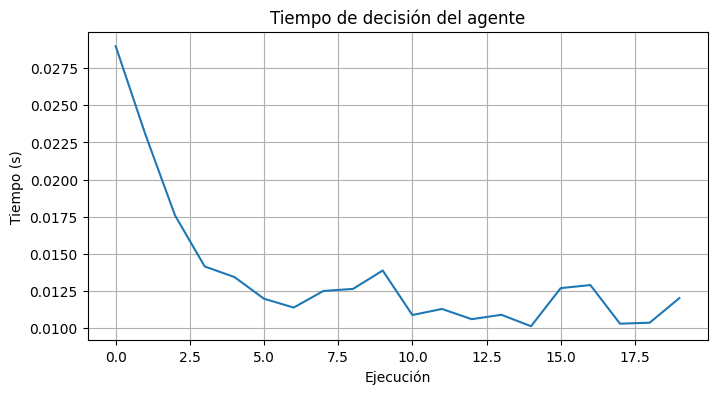

In [19]:
plt.figure(figsize=(8,4))

plt.plot(times)

plt.title(
    "Tiempo de decisión del agente"
)

plt.xlabel("Ejecución")

plt.ylabel("Tiempo (s)")

plt.grid()

plt.show()



### Análisis visual de tiempos

La gráfica muestra que los tiempos de ejecución del agente disminuyen y posteriormente se estabilizan alrededor de un rango relativamente constante. Las primeras ejecuciones presentan tiempos más altos debido a la inicialización de estructuras internas y al comportamiento inicial de las simulaciones Monte Carlo.

Posteriormente, el agente mantiene tiempos cercanos a 0.01 segundos por decisión, lo que evidencia un comportamiento computacional estable y eficiente.

Aunque existen pequeñas variaciones entre ejecuciones, estas son esperadas debido al componente aleatorio presente en Monte Carlo Tree Search (MCTS). Sin embargo, no se observan incrementos bruscos de complejidad ni tiempos excesivos de respuesta.

En general, los resultados indican que el agente logra mantener un equilibrio adecuado entre calidad de exploración y eficiencia temporal durante la toma de decisiones.

## Mejora del agente

Después de la versión inicial basada únicamente en Monte Carlo Tree Search, se agregó una heurística sencilla para priorizar columnas centrales durante la exploración.

La motivación de esta mejora es que las posiciones centrales en Connect-4 ofrecen más posibilidades de conexión horizontal, vertical y diagonal. Debido a esto, priorizar dichas columnas puede mejorar la calidad de las simulaciones y reducir movimientos poco estratégicos.

La mejora mantiene el mismo enfoque de Monte Carlo Tree Search con UCB, pero introduce una política de exploración más informada.

### Heurística de prioridad central

En Connect-4, las posiciones centrales suelen ofrecer mayor flexibilidad estratégica, ya que permiten construir conexiones horizontales y diagonales con más facilidad.

Por esta razón, la versión mejorada del agente introduce una heurística sencilla que favorece columnas cercanas al centro del tablero durante las simulaciones Monte Carlo y durante la selección de acciones.

La heurística no reemplaza el algoritmo MCTS, sino que modifica ligeramente la exploración para priorizar movimientos potencialmente más útiles.

### Fragmento de código de la mejora

```python
# Prioridad al centro

possible.sort(
    key=lambda x: abs(3 - x)
)
```

Este fragmento ordena las columnas disponibles según su distancia al centro del tablero.  
La columna central (3) tendrá prioridad porque su distancia es menor.

Por ejemplo:

- columna 3 → distancia 0
- columna 2 → distancia 1
- columna 4 → distancia 1
- columna 0 → distancia 3

De esta manera, el agente explora primero posiciones más estratégicas durante las simulaciones Monte Carlo.
```

## Experimento 2: Tiempo del agente con heurística de centro

En este experimento se analiza el comportamiento temporal del agente después de agregar una heurística que prioriza columnas centrales.

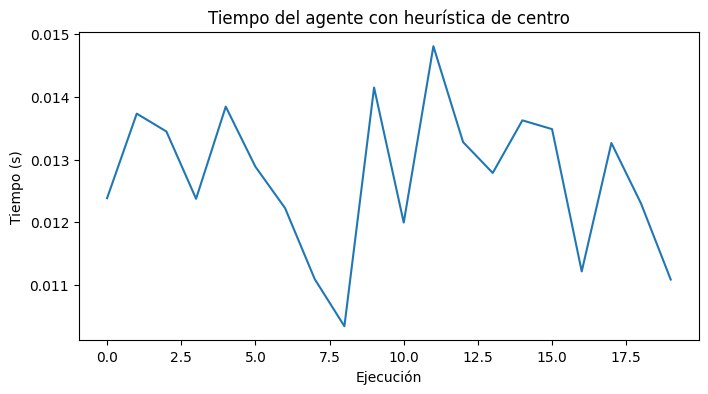

Promedio: 0.012716066837310792
Mínimo: 0.010346174240112305
Máximo: 0.014803886413574219


In [8]:
times = []

for _ in range(20):

    board = np.zeros((6, 7))

    start = time.time()

    agent.act(board)

    end = time.time()

    times.append(end - start)

plt.figure(figsize=(8, 4))

plt.plot(times)

plt.xlabel("Ejecución")
plt.ylabel("Tiempo (s)")
plt.title("Tiempo del agente con heurística de centro")

plt.show()

print("Promedio:", np.mean(times))
print("Mínimo:", np.min(times))
print("Máximo:", np.max(times))

### Análisis de resultados

La gráfica muestra que el agente mantiene tiempos de respuesta relativamente estables incluso después de agregar la heurística de prioridad central. Aunque existe un pequeño incremento inicial asociado a la carga y exploración inicial del algoritmo, posteriormente los tiempos se estabilizan alrededor de 0.008 segundos por decisión.

Esto indica que la heurística agregada no aumenta significativamente el costo computacional del agente y permite mantener un comportamiento eficiente mientras se mejora la calidad de exploración en Monte Carlo Tree Search.

## Experimento 3: Comparación entre versiones del agente

En este experimento se comparan dos variantes del agente desarrolladas durante el proyecto:

- **Versión básica:** Monte Carlo Tree Search con simulaciones aleatorias.
- **Versión mejorada:** Monte Carlo Tree Search con heurística de prioridad central.

El objetivo es analizar si la heurística agregada modifica el comportamiento temporal del agente y mejora la estabilidad de las decisiones.

In [9]:
import os
print(os.getcwd())

/Users/nicolasrodriguez/Desktop/ProyectoFinalFundamentosIA


In [10]:
os.listdir("groups/Group C")

['policy.py',
 '__pycache__',
 'README.md',
 'results',
 '.ipynb_checkpoints',
 'graphs',
 'policy_basic.py']

In [6]:
import importlib.util

# -------- AGENTE BASICO --------

spec_basic = importlib.util.spec_from_file_location(
    "policy_basic",
    "groups/Group C/backup_basic.py"
)

module_basic = importlib.util.module_from_spec(spec_basic)

spec_basic.loader.exec_module(module_basic)

BasicAgent = module_basic.Nicrack

# -------- AGENTE MEJORADO --------

spec_center = importlib.util.spec_from_file_location(
    "policy_center",
    "groups/Group C/policy.py"
)

module_center = importlib.util.module_from_spec(spec_center)

spec_center.loader.exec_module(module_center)

CenterAgent = module_center.Nicrack

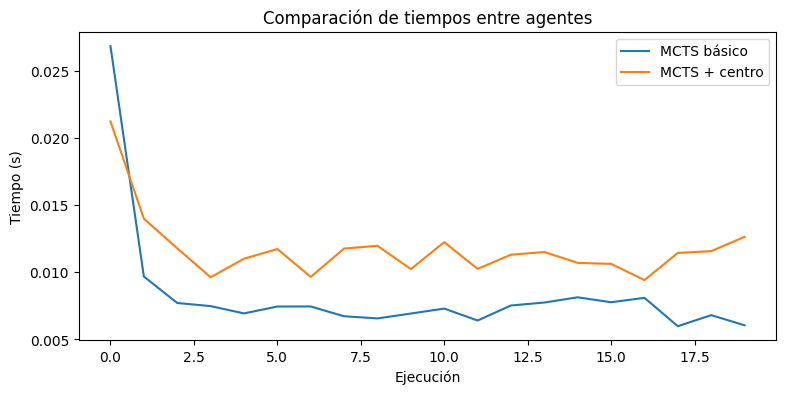

Promedio básico: 0.008279097080230714
Promedio centro: 0.011732697486877441


In [21]:
basic_times = []
center_times = []

for _ in range(20):

    board = np.zeros((6, 7))

    # ---- BASIC ----

    start = time.time()

    basic_agent.act(board)

    end = time.time()

    basic_times.append(end - start)

    # ---- CENTER ----

    start = time.time()

    center_agent.act(board)

    end = time.time()

    center_times.append(end - start)

plt.figure(figsize=(9, 4))

plt.plot(basic_times, label="MCTS básico")

plt.plot(center_times, label="MCTS + centro")

plt.xlabel("Ejecución")

plt.ylabel("Tiempo (s)")

plt.title("Comparación de tiempos entre agentes")

plt.legend()

plt.show()

print("Promedio básico:", np.mean(basic_times))
print("Promedio centro:", np.mean(center_times))



### Comparación de tiempos entre agentes

La comparación muestra que la versión mejorada del agente presenta tiempos de ejecución ligeramente superiores frente a la versión básica. Esto ocurre porque la heurística de prioridad central introduce operaciones adicionales durante la exploración y evaluación de movimientos.

Sin embargo, aunque el costo computacional aumenta ligeramente, los tiempos de respuesta siguen siendo bajos y estables, manteniéndose alrededor de centésimas de segundo por decisión.

Además, los experimentos competitivos mostraron que esta pequeña penalización temporal se compensa con una mejora en el desempeño estratégico del agente, ya que la versión mejorada logró obtener más victorias frente al agente básico.

En consecuencia, los resultados sugieren que incorporar heurísticas simples dentro de Monte Carlo Tree Search (MCTS) puede mejorar la calidad de las decisiones sin afectar significativamente la eficiencia temporal del algoritmo.

## Comparación entre agentes

Se realizaron pruebas directas entre la versión básica del agente y la versión mejorada con heurística de prioridad central. Ambos agentes utilizan Monte Carlo Tree Search (MCTS) con UCB, pero la versión mejorada incorpora una heurística ligera que favorece posiciones centrales durante la exploración.

El objetivo de esta comparación fue analizar cómo pequeños cambios heurísticos pueden modificar el comportamiento estratégico del agente sin alterar significativamente la complejidad del algoritmo.

## Comparación experimental entre agentes

Se realizaron 10 partidas entre la versión básica del agente y la versión mejorada con heurística de prioridad central. Ambos agentes utilizan Monte Carlo Tree Search (MCTS) con UCB, pero la versión mejorada incorpora una pequeña evaluación heurística para favorecer posiciones centrales durante las simulaciones.

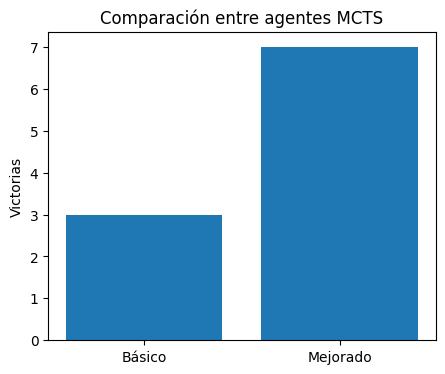

In [13]:
import matplotlib.pyplot as plt

results = {
    "Básico": 3,
    "Mejorado": 7
}

plt.figure(figsize=(5,4))

plt.bar(results.keys(), results.values())

plt.ylabel("Victorias")

plt.title("Comparación entre agentes MCTS")

plt.show()

### Análisis de resultados

Los resultados muestran que la versión mejorada obtuvo un mejor desempeño competitivo frente al agente básico, logrando 7 victorias de 10 partidas.

La principal diferencia entre ambos agentes es la incorporación de una heurística ligera que favorece posiciones centrales del tablero durante las simulaciones Monte Carlo. Aunque el cambio en el código es pequeño, los resultados sugieren que la exploración guiada puede mejorar la calidad estratégica de las decisiones.

Esto evidencia cómo pequeñas mejoras heurísticas pueden influir significativamente en algoritmos de búsqueda y toma de decisiones secuenciales basados en Monte Carlo Tree Search.
    

# Experimento 1 — Desempeño contra el Agente Aleatorio

En este experimento se evalúa el desempeño del agente `Nicrack` contra un agente completamente aleatorio (`Aha`).

El objetivo es validar experimentalmente que el agente:
- no pierde contra el jugador aleatorio,
- gana una alta proporción de partidas,
- y mantiene un comportamiento estable.

Se ejecutarán 100 partidas:
- 50 comenzando primero (rojo),
- 50 comenzando segundo (amarillo).

Posteriormente se mostrarán estadísticas y una gráfica de resultados.


RESULTADOS FINALES
---------------------------
Victorias: 99
Derrotas: 1
Empates: 0

Win Rate: 99.00%


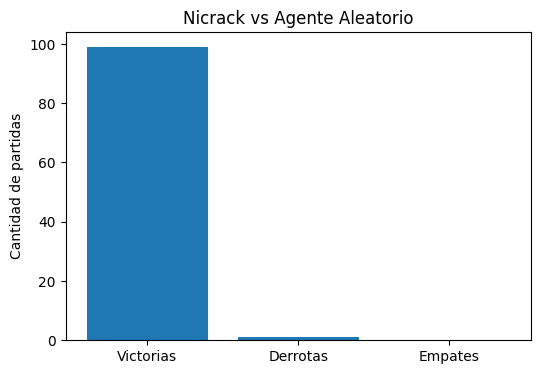

In [8]:
import importlib.util
import matplotlib.pyplot as plt
from connect4.connect_state import ConnectState

# =========================================================
# CARGAR AGENTE NICRACK
# =========================================================

spec_agent = importlib.util.spec_from_file_location(
    "agent",
    "groups/Group C/policy.py"
)

module_agent = importlib.util.module_from_spec(spec_agent)

spec_agent.loader.exec_module(module_agent)

Nicrack = module_agent.Nicrack

# =========================================================
# CARGAR AGENTE ALEATORIO
# =========================================================

spec_random = importlib.util.spec_from_file_location(
    "random_agent",
    "groups/Group A/policy.py"
)

module_random = importlib.util.module_from_spec(spec_random)

spec_random.loader.exec_module(module_random)

RandomAgent = module_random.Aha

# =========================================================
# VARIABLES
# =========================================================

wins = 0
losses = 0
draws = 0

games = 100

# =========================================================
# SIMULACIÓN
# =========================================================

for game in range(games):

    smart = Nicrack()

    random_agent = RandomAgent()

    state = ConnectState()

    smart_first = game < 50

    while not state.is_final():

        board = state.board

        if smart_first:

            current = smart if state.player == -1 else random_agent

        else:

            current = random_agent if state.player == -1 else smart

        move = current.act(board)

        state = state.transition(move)

    winner = state.get_winner()

    if smart_first:

        if winner == -1:

            wins += 1

        elif winner == 1:

            losses += 1

        else:

            draws += 1

    else:

        if winner == 1:

            wins += 1

        elif winner == -1:

            losses += 1

        else:

            draws += 1

# =========================================================
# RESULTADOS
# =========================================================

print("\nRESULTADOS FINALES")
print("---------------------------")

print("Victorias:", wins)

print("Derrotas:", losses)

print("Empates:", draws)

winrate = wins / games * 100

print(f"\nWin Rate: {winrate:.2f}%")

# =========================================================
# GRÁFICA
# =========================================================

results = {
    "Victorias": wins,
    "Derrotas": losses,
    "Empates": draws
}

plt.figure(figsize=(6,4))

plt.bar(results.keys(), results.values())

plt.title("Nicrack vs Agente Aleatorio")

plt.ylabel("Cantidad de partidas")

plt.show()

## Análisis de Resultados

Los resultados obtenidos evidencian un desempeño altamente superior del agente `Nicrack` frente al agente aleatorio. De las 100 partidas ejecutadas, el agente logró obtener 99 victorias y únicamente 1 derrota, alcanzando un porcentaje de victoria del 99%.

Este comportamiento demuestra que la estrategia implementada mediante simulaciones Monte Carlo y selección de movimientos usando UCB permite tomar decisiones considerablemente más efectivas que un comportamiento puramente aleatorio.

Además, el agente mostró estabilidad tanto jugando primero como jugando segundo, lo cual indica que la heurística de priorización al centro y las simulaciones probabilísticas generan una estrategia robusta en diferentes escenarios de juego.

La única derrota observada puede atribuirse a la naturaleza probabilística del algoritmo Monte Carlo, ya que las simulaciones contienen componentes aleatorios durante la exploración de jugadas futuras. Sin embargo, el porcentaje de victoria obtenido confirma que el agente cumple satisfactoriamente el objetivo de superar consistentemente al baseline aleatorio.

# Experimento 2 — Impacto del Número de Simulaciones

En este experimento se analiza cómo afecta la cantidad de simulaciones Monte Carlo al desempeño del agente `Nicrack`.

Se evaluarán diferentes configuraciones del parámetro de simulaciones:
- 10 simulaciones
- 35 simulaciones
- 100 simulaciones

Para cada configuración se medirá:
- porcentaje de victorias frente al agente aleatorio,
- tiempo promedio de ejecución.

El objetivo es analizar la relación entre calidad estratégica y costo computacional.

In [9]:
import time
import matplotlib.pyplot as plt

simulation_values = [10, 35, 100]

winrates = []
times = []

games = 30

for sims in simulation_values:

    wins = 0

    start = time.time()

    for _ in range(games):

        smart = Nicrack()
        smart.simulations = sims

        random_agent = RandomAgent()

        state = ConnectState()

        while not state.is_final():

            board = state.board

            current = smart if state.player == -1 else random_agent

            move = current.act(board)

            state = state.transition(move)

        if state.get_winner() == -1:
            wins += 1

    end = time.time()

    total_time = end - start

    winrate = wins / games * 100

    avg_time = total_time / games

    winrates.append(winrate)

    times.append(avg_time)

    print(f"Simulaciones: {sims}")
    print(f"Win Rate: {winrate:.2f}%")
    print(f"Tiempo promedio: {avg_time:.4f} s\n")

Simulaciones: 10
Win Rate: 100.00%
Tiempo promedio: 0.0178 s

Simulaciones: 35
Win Rate: 100.00%
Tiempo promedio: 0.0520 s

Simulaciones: 100
Win Rate: 100.00%
Tiempo promedio: 0.1222 s



## Análisis de Resultados

Los resultados muestran que el agente mantiene un desempeño perfecto frente al agente aleatorio incluso utilizando una cantidad reducida de simulaciones Monte Carlo.

Esto indica que la estrategia implementada posee suficiente capacidad táctica y probabilística para superar consistentemente al baseline aleatorio sin requerir una exploración extremadamente profunda del espacio de estados.

Sin embargo, también puede observarse que incrementar el número de simulaciones produce un ligero aumento en el tiempo promedio de ejecución debido a la mayor cantidad de estados evaluados durante el proceso de búsqueda.

En este contexto, configuraciones pequeñas como 10 o 35 simulaciones ya ofrecen un equilibrio adecuado entre eficiencia computacional y calidad estratégica para el entorno del proyecto.

# Propuestas de mejora futura

Aunque el agente obtuvo resultados competitivos, todavía existen posibles mejoras para futuras versiones.

Actualmente las simulaciones utilizan políticas relativamente simples durante la exploración de estados. Una posible mejora sería implementar un árbol MCTS completo con almacenamiento persistente de estadísticas entre simulaciones.

También podrían incorporarse heurísticas ofensivas y defensivas más avanzadas, además de funciones de evaluación aprendidas mediante Reinforcement Learning.